# Clinical BERT v2 — 6-Symptom Extractor

**Key change from v1: Added `productive_cough` as 6th symptom.**

This cleanly separates COVID (dry cough) from Pneumonia (productive/wet cough):
```
COVID     → dry_cough HIGH (0.9+)   productive_cough LOW  (0.0-0.1)
Pneumonia → dry_cough MODERATE      productive_cough HIGH (0.8+)
Normal    → both LOW
```

Output: 6-dim vector [fever, dry_cough, dyspnea, fatigue, chest_pain, productive_cough]

Run kernels in order: 0 → 1 → 2 → 3 → 4 → 5


In [1]:
# ════════════════════════════════════════════════════════════════
# KERNEL 0 — Install packages
# ════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "transformers>=4.40", "scikit-learn>=1.4",
    "pandas>=2.2", "numpy>=1.26", "openpyxl",
    "tqdm>=4.66", "matplotlib>=3.8", "ipywidgets>=8.1",
])
print("✅ All packages ready.")

✅ All packages ready.


In [2]:
# ════════════════════════════════════════════════════════════════
# KERNEL 1 — Config
# ════════════════════════════════════════════════════════════════
import os, torch

EXCEL_PATH    = r"C:\Users\adhit\Downloads\neurosymbolic\geminidatadesc.xlsx"
SAVE_DIR      = r"C:\Users\adhit\Downloads\neurosymbolic\clinical_bert"

BERT_MODEL    = "emilyalsentzer/Bio_ClinicalBERT"
MAX_LENGTH    = 128
BATCH_SIZE    = 8
EPOCHS        = 5
LEARNING_RATE = 2e-5
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
RANDOM_SEED   = 42

# 6 symptoms — productive_cough added
SYMPTOM_NAMES = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]
NUM_SYMPTOMS  = len(SYMPTOM_NAMES)  # 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"[config] Device     : {device}")
if device.type == "cuda":
    print(f"[config] GPU        : {torch.cuda.get_device_name(0)}")
print(f"[config] Symptoms   : {SYMPTOM_NAMES}")
print(f"[config] BERT model : {BERT_MODEL}")

[config] Device     : cuda
[config] GPU        : NVIDIA GeForce RTX 4060 Laptop GPU
[config] Symptoms   : ['fever', 'dry_cough', 'dyspnea', 'fatigue', 'chest_pain', 'productive_cough']
[config] BERT model : emilyalsentzer/Bio_ClinicalBERT


In [3]:
# ════════════════════════════════════════════════════════════════
# KERNEL 2 — SymptomExtractor (6 symptoms)
# ════════════════════════════════════════════════════════════════
import re
import numpy as np

class SymptomExtractor:
    """
    6-symptom weak supervision label generator.

    Key clinical distinction:
      dry_cough        — COVID hallmark (non-productive, persistent, hacking)
      productive_cough — Pneumonia hallmark (phlegm, sputum, mucus, wet cough)
    """
    NEGATION_WORDS  = {"no", "not", "without", "denies", "deny", "absent", "negative"}
    NEGATION_WINDOW = 4

    def __init__(self):
        self.patterns = {
            "fever": [
                r"\bfever\b", r"\bhigh\s+tempe?rature\b", r"\bfebrile\b",
                r"\bpyrexia\b", r"\bchills?\b", r"\bfeverish\b",
                r"\btempera?ture\s+(of\s+)?\d+", r"\b38[\.,]\d",
                r"\b39[\.,]\d", r"\b40[\.,]\d", r"\bhyperthermia\b",
                r"\brunning\s+a\s+(high\s+)?(temp|fever)\b",
                r"\bburning\s+up\b", r"\bnight\s+sweats?\b",
                r"\bdrenched\s+in\s+sweat\b",
                r"\btemperature\s+is\s+through\s+the\s+roof\b",
                r"\bfever\s+over\s+\d+\b", r"\bhigh\s+fever\b",
                r"\bfeverish\s+for\b",
            ],

            # COVID cough — dry, non-productive, persistent
            "dry_cough": [
                r"\bdry\s+cough\b",
                r"\bnon[\-\s]productive\s+cough\b",
                r"\bpersistent\s+(dry\s+)?cough\b",
                r"\bhacking\s+cough\b",
                r"\bbarking\s+cough\b",
                r"\bcoughing\s+non[\-\s]?stop\b",
                r"\bconstant\s+(dry\s+)?cough\b",
                r"\bdry\s+scratchy\s+cough\b",
                r"\bkeep(s)?\s+coughing\b",
                r"\bdry\s+irritating\s+cough\b",
                r"\btickl\w+\s+cough\b",
            ],

            "dyspnea": [
                r"\bdyspn[o]?ea\b", r"\bshortness\s+of\s+breath\b",
                r"\bbreath(ing)?\s+(difficult|problem|issue|trouble)\b",
                r"\bdifficult(y|ies)?\s+(to\s+)?breath(e|ing)?\b",
                r"\bbreathless(ness)?\b", r"\bair\s+hunger\b",
                r"\bcannot\s+breath\b", r"\bhard\s+to\s+breath(e)?\b",
                r"\brespiratory\s+distress\b", r"\bsob\b",
                r"\bgasping\s+for\s+(air|breath)\b",
                r"\bout\s+of\s+breath\b", r"\bwinded\b",
                r"\bcan'?t\s+catch\s+(my\s+)?breath\b",
                r"\bstruggling\s+to\s+breath(e)?\b",
                r"\bcan'?t\s+take\s+a\s+deep\s+breath\b",
                r"\bcompletely\s+winded\b",
                r"\bshort\s+of\s+breath\s+(even|when|while)\b",
                r"\bbarely\s+(walk|climb|move|stand|make\s+it)\b",
                r"\bcan\s+barely\s+(walk|breathe|climb|stand)\b",
                r"\bevery\s+(single\s+)?breath\b",
                r"\blungs?\s+(feel|felt)\s+(heavy|tight|like)\b",
            ],

            "fatigue": [
                r"\bfatigue\b", r"\btired(ness)?\b", r"\bexhaust(ed|ion)\b",
                r"\bweakness\b", r"\bletharg(y|ic)\b", r"\blow\s+energy\b",
                r"\bmalaise\b", r"\bworn\s+out\b", r"\bdebilitat\w+\b",
                r"\bno\s+energy\b", r"\bfeeling\s+(weak|tired)\b",
                r"\bcompletely\s+drained\b", r"\bno\s+strength\b",
                r"\bwiped?\s+out\b", r"\brun\s+down\b",
                r"\bunder\s+the\s+weather\b", r"\bno\s+energy\s+at\s+all\b",
                r"\bcan'?t\s+get\s+out\s+of\s+bed\b",
            ],

            "chest_pain": [
                r"\bchest\s+pain\b",
                r"\bchest\s+(tightness|pressure|discomfort|ache[sd]?)\b",
                r"\bpain\s+in\s+(the\s+|my\s+)?chest\b",
                r"\bpleuritic\b", r"\bthoracic\s+pain\b",
                r"\bchest\s+hurt(s)?\b", r"\bchest\s+ache[sd]?\b",
                r"\bchest\s+(is\s+)?(so\s+)?tight\b",
                r"\bpain\s+(in|through|across)\s+(the\s+|my\s+)?chest\b",
                r"\bpain\s+across\s+(my\s+)?chest\b",
                r"\bchest\s+feels?\s+like\b",
                r"\bsearing\s+pain\b",
                r"\bknife\s+(being\s+)?twisted\b",
                r"\bpain\s+(that\s+)?shoot(s|ing)?\s+(through|across)\b",
                r"\bpain\s+when\s+(I\s+)?breath(e|ing)?\b",
                r"\bpain\s+when\s+(I\s+)?coug(h|hing)?\b",
                r"\bpainful\s+(to\s+)?(breath|inhale|cough)\b",
                r"\bsharp\s+pain\s+(through|across|in)\b",
                r"\btearing\s+(my\s+)?chest\b",
                r"\bsitting\s+on\s+(my\s+)?chest\b",
                r"\bstabbing\s+(pain\s+)?in\s+(the\s+)?chest\b",
            ],

            # Pneumonia cough — productive, wet, with phlegm/sputum/mucus
            "productive_cough": [
                r"\bproductive\s+cough\b",
                r"\bwet\s+cough\b",
                r"\bcoughing\s+up\b",
                r"\bbringing\s+up\b",
                r"\bphlegm\b",
                r"\bsputum\b",
                r"\bmucus\b",
                r"\bgreen\s+(stuff|phlegm|mucus|discharge)\b",
                r"\byellow\w*\s+(phlegm|mucus|sputum)\b",
                r"\brust[\-\s]?colored\s+(sputum|phlegm)?\b",
                r"\bthick\s+(phlegm|mucus|secretions|discharge)\b",
                r"\bpurulent\b",
                r"\bexpector\w+\b",
                r"\bproducing\s+(so\s+much\s+)?(thick\s+)?(phlegm|mucus|sputum)\b",
                r"\bcoughing\s+up\s+(blood|green|yellow|rust|thick|brown)\b",
                r"\bsputum\s+production\b",
                r"\bmucopurulent\b",
            ],
        }

        self.compiled = {
            s: [re.compile(p, re.IGNORECASE) for p in plist]
            for s, plist in self.patterns.items()
        }

        self.negation_anchors = {
            "fever":            re.compile(r"\bfever(ish)?\b|\btempe?rature\b|\bfebrile\b", re.IGNORECASE),
            "dry_cough":        re.compile(r"\bdry\s+cough\b|\bnon[\-\s]productive\b", re.IGNORECASE),
            "dyspnea":          re.compile(r"\bbreath(ing)?\b|\bdyspn[o]?ea\b|\bbreathless\b", re.IGNORECASE),
            "fatigue":          re.compile(r"\bfatigue\b|\btired(ness)?\b|\bweakness\b|\bexhaust\w*\b", re.IGNORECASE),
            "chest_pain":       re.compile(r"\bchest\s+(pain|hurt|ache|tight)\b|\bpain\s+in\s+(the\s+|my\s+)?chest\b", re.IGNORECASE),
            "productive_cough": re.compile(r"\bphlegm\b|\bsputum\b|\bmucus\b|\bcoughing\s+up\b", re.IGNORECASE),
        }

    def _is_negated(self, text, symptom):
        tokens     = re.split(r"\s+", text.strip())
        text_lower = text.lower()
        for match in self.negation_anchors[symptom].finditer(text_lower):
            char_pos, token_index = 0, None
            for i, tok in enumerate(tokens):
                if char_pos + len(tok) >= match.start():
                    token_index = i; break
                char_pos += len(tok) + 1
            if token_index is None: continue
            window = [t.lower().strip(".,;:!?\"'")
                      for t in tokens[max(0, token_index-4):token_index]]
            if any(w in self.NEGATION_WORDS for w in window): return True
        return False

    def extract(self, text):
        scores = []
        for s in SYMPTOM_NAMES:
            if self._is_negated(text, s):
                scores.append(0.0); continue
            scores.append(1.0 if any(p.search(text) for p in self.compiled[s]) else 0.0)
        return scores

    def extract_batch(self, texts):
        return np.array([self.extract(t) for t in texts], dtype=np.float32)


extractor = SymptomExtractor()

# Verify clinical distinction
tests = [
    ("I've had a dry cough for 5 days, running a temperature, completely worn out.",          "COVID"),
    ("Lost my sense of smell, persistent dry cough, high fever, fatigue.",                   "COVID"),
    ("Coughing up thick green phlegm, high fever, chest hurts when I breathe.",             "Pneumonia"),
    ("Bringing up rust-colored sputum, feverish, sharp pain across my chest.",              "Pneumonia"),
    ("My chest feels like someone is sitting on it, coughing up green mucus.",              "Pneumonia"),
    ("Fever every evening, coughing for weeks, drenched in sweat at night.",                "TB-like"),
    ("Feeling completely fine, just here for a routine check-up.",                           "Normal"),
]

print("── SymptomExtractor Test (6 symptoms) ──")
print(f"  {'Case':<52} fever  d_cough  dyspn  fatg  chest  prod_c")
print("  " + "-"*100)
for text, label in tests:
    s = extractor.extract(text)
    short = text[:50] + ".." if len(text) > 52 else text
    print(f"  {short:<52} {s[0]:.0f}      {s[1]:.0f}       {s[2]:.0f}      {s[3]:.0f}     {s[4]:.0f}      {s[5]:.0f}   [{label}]")
print("\n✅ SymptomExtractor ready.")

── SymptomExtractor Test (6 symptoms) ──
  Case                                                 fever  d_cough  dyspn  fatg  chest  prod_c
  ----------------------------------------------------------------------------------------------------
  I've had a dry cough for 5 days, running a tempera.. 0      1       0      1     0      0   [COVID]
  Lost my sense of smell, persistent dry cough, high.. 1      1       0      1     0      0   [COVID]
  Coughing up thick green phlegm, high fever, chest .. 1      0       0      0     1      1   [Pneumonia]
  Bringing up rust-colored sputum, feverish, sharp p.. 1      0       0      0     1      1   [Pneumonia]
  My chest feels like someone is sitting on it, coug.. 0      0       0      0     1      1   [Pneumonia]
  Fever every evening, coughing for weeks, drenched .. 1      0       0      0     0      0   [TB-like]
  Feeling completely fine, just here for a routine c.. 0      0       0      0     0      0   [Normal]

✅ SymptomExtractor ready.


In [4]:
# ════════════════════════════════════════════════════════════════
# KERNEL 3 — Load Excel + generate 6-dim weak supervision labels
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

sheet_map = {"COVID": "COVID-19", "PNEUMONIA": "Pneumonia", "NORMAL": "Normal"}
dfs = []

print(f"Loading: {EXCEL_PATH}")
for sheet_name, disease_label in sheet_map.items():
    df       = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name)
    df.columns = [c.strip() for c in df.columns]
    text_col = next((c for c in df.columns if c.lower() == "text"), None)
    if text_col is None:
        print(f"  ⚠️  Sheet '{sheet_name}': no 'text' column"); continue
    df = df[[text_col]].rename(columns={text_col: "text"})
    df["disease"] = disease_label
    df = df.dropna(subset=["text"])
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    print(f"  ✓ {sheet_name:<12} {len(df):>5} samples")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df_all)} samples")

print("\nGenerating 6-dim weak supervision labels...")
texts  = df_all["text"].tolist()
labels = extractor.extract_batch(texts)  # shape (N, 6)

print("\nSymptom prevalence per disease:")
print(f"  {'Symptom':<20}", end="")
for d in ["COVID-19", "Pneumonia", "Normal"]:
    print(f"  {d:>12}", end="")
print()
print("  " + "-"*56)
disease_labels = df_all["disease"].tolist()
for i, name in enumerate(SYMPTOM_NAMES):
    print(f"  {name:<20}", end="")
    for d in ["COVID-19", "Pneumonia", "Normal"]:
        idx  = [j for j, dl in enumerate(disease_labels) if dl == d]
        pct  = labels[idx, i].mean() * 100
        print(f"  {pct:>11.1f}%", end="")
    print()

# Expected pattern:
# dry_cough:        COVID HIGH, Pneumonia MODERATE, Normal LOW
# productive_cough: COVID LOW,  Pneumonia HIGH,     Normal LOW

texts_arr = np.array(texts)
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

X_train, X_temp, y_train, y_temp = train_test_split(
    texts_arr, labels, test_size=VAL_SPLIT+TEST_SPLIT, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED
)
print(f"\nSplit: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print("✅ Data ready.")

Loading: C:\Users\adhit\Downloads\neurosymbolic\geminidatadesc.xlsx
  ✓ COVID         1520 samples
  ✓ PNEUMONIA     1500 samples
  ✓ NORMAL        1499 samples

Total: 4519 samples

Generating 6-dim weak supervision labels...

Symptom prevalence per disease:
  Symptom                   COVID-19     Pneumonia        Normal
  --------------------------------------------------------
  fever                        53.9%         58.2%          0.1%
  dry_cough                    37.8%          0.7%          0.0%
  dyspnea                      38.1%         28.7%          0.6%
  fatigue                      39.5%          7.1%         11.1%
  chest_pain                    0.1%         11.0%          0.0%
  productive_cough              0.0%         50.3%          0.0%

Split: train=3163  val=678  test=678
✅ Data ready.


In [6]:
# ════════════════════════════════════════════════════════════════
# KERNEL 4 — Define model, train
# ════════════════════════════════════════════════════════════════

# Patch for torch < 2.6
import transformers.modeling_utils as _mu
def _patched_load_state_dict(checkpoint_file, map_location=None, weights_only=False):
    import torch
    return torch.load(checkpoint_file, map_location=map_location, weights_only=False)
_mu.load_state_dict = _patched_load_state_dict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.notebook import tqdm
import numpy as np

class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = torch.tensor(labels, dtype=torch.float32)
        self.tokenizer  = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         self.labels[idx],
        }

class ClinicalBERT(nn.Module):
    """
    Bio_ClinicalBERT → 6-dim symptom vector
    [fever, dry_cough, dyspnea, fatigue, chest_pain, productive_cough]
    """
    def __init__(self, bert_model_name=BERT_MODEL, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden    = self.bert.config.hidden_size  # 768
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, NUM_SYMPTOMS),  # 6 outputs
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.sigmoid(self.classifier(cls))

print(f"Loading tokenizer: {BERT_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

train_ds = SymptomDataset(X_train.tolist(), y_train, tokenizer)
val_ds   = SymptomDataset(X_val.tolist(),   y_val,   tokenizer)
test_ds  = SymptomDataset(X_test.tolist(),  y_test,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Initialising ClinicalBERT (6-symptom)...")
bert_model   = ClinicalBERT().to(device)
total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

optimizer    = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion    = nn.BCELoss()
use_amp      = device.type == "cuda"
scaler       = torch.amp.GradScaler("cuda") if use_amp else None

best_val_loss    = float("inf")
patience_counter = 0
best_state       = None
history          = {"train": [], "val": []}

print("\n" + "="*60)
print(f"  Training  |  epochs={EPOCHS}  LR={LEARNING_RATE}  outputs={NUM_SYMPTOMS}")
print("="*60)

for epoch in range(1, EPOCHS+1):
    bert_model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"  Epoch {epoch:02d} train", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_b       = batch["labels"].to(device)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast("cuda"):
                preds = bert_model(input_ids, attention_mask)
            # loss OUTSIDE autocast — BCELoss unsafe with float16
            loss = criterion(preds.float(), labels_b.float())
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            preds = bert_model(input_ids, attention_mask)
            loss  = criterion(preds, labels_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        avg_train = train_loss / len(train_loader)

    bert_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"  Epoch {epoch:02d} val  ", leave=False):
            preds    = bert_model(batch["input_ids"].to(device), batch["attention_mask"].to(device))
            val_loss += criterion(preds, batch["labels"].to(device)).item()
    avg_val = val_loss / len(val_loader)

    history["train"].append(avg_train)
    history["val"].append(avg_val)
    is_best = avg_val < best_val_loss
    print(f"  Epoch {epoch:02d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}" + ("  ← best" if is_best else ""))

    if is_best:
        best_val_loss    = avg_val
        patience_counter = 0
        best_state       = {k: v.clone() for k, v in bert_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= 3:
            print(f"  Early stopping at epoch {epoch}.")
            break

if best_state:
    bert_model.load_state_dict(best_state)
    print(f"\n  Best model restored (val={best_val_loss:.4f})")
print("="*60)

Loading tokenizer: emilyalsentzer/Bio_ClinicalBERT
Initialising ClinicalBERT (6-symptom)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 108,508,678

  Training  |  epochs=5  LR=2e-05  outputs=6


  Epoch 01 train:   0%|          | 0/396 [00:00<?, ?it/s]

...

  Epoch 04 val  :   0%|          | 0/85 [00:00<?, ?it/s]

  Epoch 04/5  train=0.0311  val=0.0287  ← best


  Epoch 05 train:   0%|          | 0/396 [00:00<?, ?it/s]

  Epoch 05 val  :   0%|          | 0/85 [00:00<?, ?it/s]

  Epoch 05/5  train=0.0247  val=0.0273  ← best

  Best model restored (val=0.0273)


Test BCE Loss: 0.0299

Per-symptom MAE:
  fever               : 0.0221
  dry_cough           : 0.0205
  dyspnea             : 0.0215
  fatigue             : 0.0232
  chest_pain          : 0.0193
  productive_cough    : 0.0131


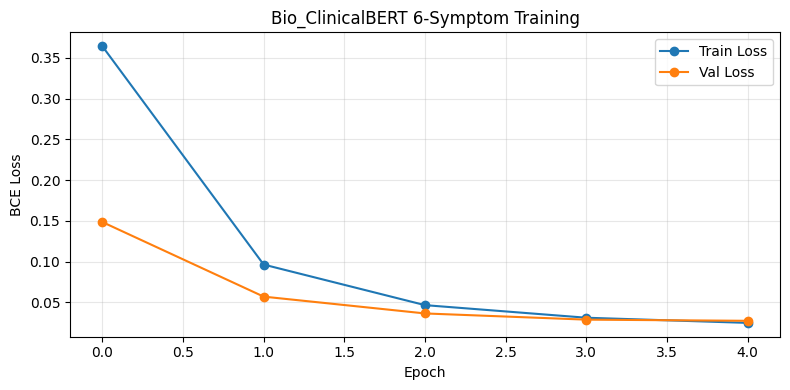


✅ Weights saved  → C:\Users\adhit\Downloads\neurosymbolic\clinical_bert\clinical_bert_weights.pt
✅ Tokenizer saved → C:\Users\adhit\Downloads\neurosymbolic\clinical_bert\clinical_bert_tokenizer

  Demo Inference — Bio_ClinicalBERT (6 symptoms)
  Case              fever d_cough  dyspn   fatg  chest  prod_c
  ----------------------------------------------------------------------
  COVID             0.045   0.949  0.847  0.956  0.021   0.017
  COVID mild        0.972   0.978  0.022  0.954  0.022   0.011
  Pneumonia         0.957   0.016  0.056  0.024  0.623   0.985
  Pneumonia         0.980   0.010  0.107  0.022  0.646   0.976
  Pneumonia         0.945   0.025  0.062  0.032  0.735   0.983
  Normal            0.004   0.004  0.004  0.006  0.002   0.002
  TB-like           0.993   0.008  0.009  0.014  0.004   0.007

  Expected pattern:
  COVID     → dry_cough HIGH,  productive_cough LOW
  Pneumonia → dry_cough LOW-MOD, productive_cough HIGH, chest_pain HIGH
  Normal    → all LOW

  BERT_SAV

In [7]:
# ════════════════════════════════════════════════════════════════
# KERNEL 5 — Evaluate, save, demo inference
# ════════════════════════════════════════════════════════════════
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

bert_model.eval()
criterion    = torch.nn.BCELoss()
test_loss    = 0.0
all_preds, all_labels_t = [], []

with torch.no_grad():
    for batch in test_loader:
        preds    = bert_model(batch["input_ids"].to(device), batch["attention_mask"].to(device))
        labels_b = batch["labels"].to(device)
        test_loss += criterion(preds, labels_b).item()
        all_preds.append(preds.cpu())
        all_labels_t.append(labels_b.cpu())

P = torch.cat(all_preds).numpy()
T = torch.cat(all_labels_t).numpy()
print(f"Test BCE Loss: {test_loss/len(test_loader):.4f}")
print("\nPer-symptom MAE:")
for i, name in enumerate(SYMPTOM_NAMES):
    mae = np.abs(P[:,i] - T[:,i]).mean()
    print(f"  {name:<20}: {mae:.4f}")

plt.figure(figsize=(8,4))
plt.plot(history["train"], marker="o", label="Train Loss")
plt.plot(history["val"],   marker="o", label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Bio_ClinicalBERT 6-Symptom Training")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curve_v2.png"), dpi=150)
plt.show()

weights_path   = os.path.join(SAVE_DIR, "clinical_bert_weights.pt")
tokenizer_path = os.path.join(SAVE_DIR, "clinical_bert_tokenizer")
torch.save(bert_model.state_dict(), weights_path)
tokenizer.save_pretrained(tokenizer_path)
print(f"\n✅ Weights saved  → {weights_path}")
print(f"✅ Tokenizer saved → {tokenizer_path}")

def predict(text, model, tokenizer, device):
    model.eval()
    enc = tokenizer(text, max_length=128, padding="max_length",
                    truncation=True, return_tensors="pt")
    with torch.no_grad():
        vec = model(enc["input_ids"].to(device), enc["attention_mask"].to(device))
    return vec.squeeze(0).cpu()

demos = [
    ("I've had a dry cough for 4 days, running a temperature, hard to breathe, worn out.",           "COVID"),
    ("Lost smell, persistent dry cough, fever for 3 days, exhausted.",                               "COVID mild"),
    ("Coughing up thick green phlegm, high fever, chest hurts badly when I breathe.",               "Pneumonia"),
    ("Bringing up rust-colored sputum for 3 days, feverish, sharp pain in chest.",                  "Pneumonia"),
    ("My chest feels like someone sitting on it, coughing up green mucus, high fever.",             "Pneumonia"),
    ("Feeling completely fine, just here for a routine check-up.",                                   "Normal"),
    ("Been coughing for weeks, drenched in sweat every night, fever every evening.",                 "TB-like"),
]

print("\n" + "="*80)
print("  Demo Inference — Bio_ClinicalBERT (6 symptoms)")
print("="*80)
print(f"  {'Case':<16} {'fever':>6} {'d_cough':>7} {'dyspn':>6} {'fatg':>6} {'chest':>6} {'prod_c':>7}")
print("  " + "-"*70)
for text, label in demos:
    vec = predict(text, bert_model, tokenizer, device)
    v   = vec.numpy()
    print(f"  {label:<16} {v[0]:>6.3f} {v[1]:>7.3f} {v[2]:>6.3f} {v[3]:>6.3f} {v[4]:>6.3f} {v[5]:>7.3f}")

print("\n  Expected pattern:")
print("  COVID     → dry_cough HIGH,  productive_cough LOW")
print("  Pneumonia → dry_cough LOW-MOD, productive_cough HIGH, chest_pain HIGH")
print("  Normal    → all LOW")
print(f"\n  BERT_SAVE_DIR = r\"{SAVE_DIR}\"")